In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib
from scipy.io import wavfile
import concurrent.futures
from tqdm import tqdm
import tensorflow as tf
import librosa
from tensorflow import keras
import IPython.display as ipd
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report
from ai_edge_litert.interpreter import Interpreter

### 1. Loading the Dataset

In [3]:
def load_dataset(path,targets):
    dataset_path=pathlib.Path(path)
    dataset=[]
    for folder in dataset_path.iterdir():
        if folder.name not in targets:
            label="unknown"
        else:
            label=folder.name
        aud_files=list(folder.glob("*.wav"))
        for file in aud_files:
            dataset.append({
                "file_path":str(file),
                "label":label,
                "word":folder.name
            })
    df=pd.DataFrame(dataset)
    return df

In [4]:
target_words=["on","off"]
dataset_direc=r"C:\Users\sambi\OneDrive\Desktop\Python\DL\TinyML_key_detection\audio_dataset_mix"
df_dataset=load_dataset(dataset_direc,target_words)

In [5]:
print(df_dataset['label'].value_counts())

label
unknown    60003
on          2447
off         2437
Name: count, dtype: int64


In [6]:
df_dataset.head()

,file_path,label,word
0,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,background_noise
1,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,background_noise
2,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,background_noise
3,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,background_noise
4,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,background_noise


### 2. Audio Preprocessing

In [30]:
ipd.Audio(df_dataset[df_dataset["label"]=="on"]["file_path"].iloc[-37])

In [8]:
def conv_path_to_mfcc(x):
    sr,y=wavfile.read(x)
    y=y.astype(np.float32) / np.iinfo(np.int16).max
    TARGET_SAMPLES = 16000
    if len(y)<TARGET_SAMPLES:
        padding=TARGET_SAMPLES-len(y)
        y=np.pad(y,(0,padding),"constant")
    elif len(y)>TARGET_SAMPLES:
        y=y[:TARGET_SAMPLES]
    mfcc=librosa.feature.mfcc(y=y,n_mfcc=13,sr=sr)
    return mfcc

In [9]:
df=df_dataset.copy()
with concurrent.futures.ThreadPoolExecutor() as executor:
    df['mfcc']=tqdm(executor.map(conv_path_to_mfcc, df['file_path']), total=len(df['file_path']))
df.head()

C:\Users\sambi\AppData\Local\Temp\ipykernel_13732\3311803873.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr,y=wavfile.read(x)
100%|██████████| 64887/64887 [09:12<00:00, 117.55it/s]


,file_path,label,word,mfcc
0,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,background_noise,"[[-397.15396, -211.83458, -157.31982, -145.359..."
1,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,background_noise,"[[-652.28253, -470.5834, -438.94974, -485.4298..."
2,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,background_noise,"[[-446.9462, -241.82037, -172.78632, -159.5794..."
3,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,background_noise,"[[36.82289, 68.798004, 68.52373, 68.61009, 70...."
4,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,background_noise,"[[-314.12485, -133.31142, -72.998825, -60.3655..."


In [10]:
x=np.stack(df['mfcc'])
le=LabelEncoder()
y=le.fit_transform(df['label'])


In [11]:
x.shape

(64887, 13, 32)

In [12]:
c=0
for i in range(len(x)):
    if x[i].shape[1]!=32:
        c+=1
c

0

In [13]:
original_shape=x.shape
x_flattened=x.reshape(x.shape[0], -1)
scaler=MinMaxScaler()
x_scaled_flattened=scaler.fit_transform(x_flattened)
x_scaled=x_scaled_flattened.reshape(original_shape)
x_scaled=x_scaled.reshape(-1,13,32,1)
x_scaled.shape

(64887, 13, 32, 1)

In [14]:
df0=df[df['label']=='on']
df1=df[df['label']=='off']
df2=df[df['label']=='unknown']
df0.shape,df1.shape,df2.shape

((2447, 4), (2437, 4), (60003, 4))

In [15]:
df2_new=df2.sample(2450)
df2_new.shape

(2450, 4)

In [16]:
df_new=pd.concat([df0,df1,df2_new],axis='index')
x_new=np.stack(df_new['mfcc'])
original_shape_new=x_new.shape
x_new_flattened=x_new.reshape(x_new.shape[0], -1)
new_scaler=MinMaxScaler()
x_new_scaled_flattened=scaler.transform(x_new_flattened)
x_new_scaled=x_new_scaled_flattened.reshape(original_shape_new)
x_new_scaled=x_new_scaled.reshape(-1,13,32,1)
x_new_scaled.shape

(7334, 13, 32, 1)

In [17]:
y_new=le.transform(df_new['label'])

### 3. Splitting the Dataset into Training and Test Dataset

In [18]:
# x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,stratify=y,random_state=0)
x_train,x_test,y_train,y_test=train_test_split(x_new_scaled,y_new,test_size=0.2,stratify=y_new,random_state=0)

### 4. Model Building 

In [19]:
model=keras.Sequential([
    keras.layers.Input(shape=(13,32,1)),
    keras.layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dropout(0.5,seed=0),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dropout(0.5,seed=0),
    keras.layers.Dense(3,activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3516 - loss: 1.0983
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5248 - loss: 0.9476
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6022 - loss: 0.8169
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6211 - loss: 0.7821
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6688 - loss: 0.7462
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7099 - loss: 0.6876
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7411 - loss: 0.6379
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7808 - loss: 0.5679
Epoch 9/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7994 - loss: 0.5217
Epoch 10/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8088 - loss: 0.4996
Epoch 11/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8214 - loss: 0.4777
Epoch 12/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

### 5. Model Evaluation and Classification Report

In [20]:
model.evaluate(x_test,y_test)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9196 - loss: 0.2626


[0.26261401176452637, 0.9195637106895447]

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


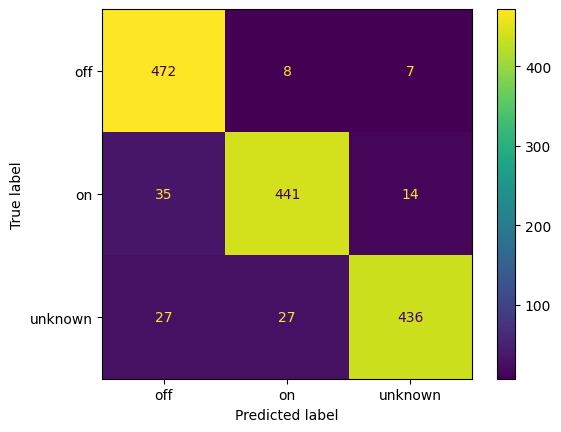

In [21]:
y_pred_prob=model.predict(x_test)
y_pred=[np.argmax(x) for x in y_pred_prob]
cm=confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=le.classes_).plot()

In [22]:
print(classification_report(y_test,y_pred,labels=[0,1,2],target_names=le.classes_))

              precision    recall  f1-score   support

         off       0.88      0.97      0.92       487
          on       0.93      0.90      0.91       490
     unknown       0.95      0.89      0.92       490

    accuracy                           0.92      1467
   macro avg       0.92      0.92      0.92      1467
weighted avg       0.92      0.92      0.92      1467



In [35]:
mfcc=conv_path_to_mfcc(df_dataset[df_dataset["label"]=="on"]["file_path"].iloc[-81])
org_shape=mfcc.shape
test_mfcc=mfcc.reshape(1,-1)
test_mfcc=scaler.transform(test_mfcc)
test_mfcc=mfcc.reshape(1,13,32,1)
test_mfcc.shape

(1, 13, 32, 1)

In [36]:
le.classes_[np.argmax(model.predict(test_mfcc))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


'off'

In [31]:
ipd.Audio(df_dataset[df_dataset["label"]=="on"]["file_path"].iloc[-81])

### 6. Model Compression

In [ ]:
def representative_dataset_gen():
    for i in range(300):
        sample = x_train[i:i+1].astype(np.float32)
        yield [sample]

In [41]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_quant_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\sambi\AppData\Local\Temp\tmp3dr4qw3b\assets


INFO:tensorflow:Assets written to: C:\Users\sambi\AppData\Local\Temp\tmp3dr4qw3b\assets


Saved artifact at 'C:\Users\sambi\AppData\Local\Temp\tmp3dr4qw3b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13, 32, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2791321197776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2791321199696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2791321199504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2791321199888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2791321196432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2791321204496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2791321200080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2791321200656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2791321198928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2791321201040: TensorSpec(shape=(), dtype=tf.resource, name=None)


C:\Users\sambi\AppData\Roaming\Python\Python313\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [43]:
with open("quant_model.tflite", "wb") as f:
    f.write(tflite_quant_model)

In [ ]:
interpreter = Interpreter(model_path="quant_model.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]
input_scale, input_zero_point = input_details["quantization"]
correct_predictions = 0
for i in range(len(x_test)):
    sample = x_test[i].reshape(1,13,32,1).astype(np.float32)
    if input_scale != 0.0:
        sample = sample / input_scale + input_zero_point
    sample = sample.astype(np.int8)
    interpreter.set_tensor(input_details["index"], sample)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details["index"])
    predicted_label = np.argmax(output)
    true_label = y_test[i]
    if predicted_label == true_label:
        correct_predictions += 1
tflite_accuracy = correct_predictions / len(x_test)
print(f"Original Accuracy: 0.9196")
print(f"Quantized TFLite Accuracy: {tflite_accuracy:.4f}")

Original Accuracy: 0.9196
Quantized TFLite Accuracy: 0.9189
